In [5]:
import numpy as np
import scipy.stats as sps

from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.optimize import brentq,minimize
import h5py
import matplotlib.pyplot as plt
import numericalunits as nu
import wimprates

In [6]:
import numericalunits as nu
import numpy as np
import pandas as pd
from scipy.special import erf


import wimprates as wr

In [7]:
halo_old = wimprates.StandardHaloModel(
    v_0=220*nu.km/nu.s,
    v_esc=(580)*nu.km/nu.s,
    )

In [8]:
halo_new = wimprates.StandardHaloModel(
    v_0=235*nu.km/nu.s,
    v_esc=(580)*nu.km/nu.s,
    )

In [11]:
v_rest = np.array([0,238,0])
v_sun = np.array([11.1,12.2,7.3])
v_earth_average = np.array([29.2,-0.1,5.9])

halo_whitepaper = wimprates.StandardHaloModel(
    v_0=np.sqrt(235)*nu.km/nu.s,
    v_esc=(544)*nu.km/nu.s,
    )

In [14]:
trapezoid?

Signature: trapezoid(y, x=None, dx=1.0, axis=-1)
Docstring:
Integrate along the given axis using the composite trapezoidal rule.

If `x` is provided, the integration happens in sequence along its
elements - they are not sorted.

Integrate `y` (`x`) along each 1d slice on the given axis, compute
:math:`\int y(x) dx`.
When `x` is specified, this integrates along the parametric curve,
computing :math:`\int_t y(t) dt =
\int_t y(t) \left.\frac{dx}{dt}\right|_{x=x(t)} dt`.

Parameters
----------
y : array_like
    Input array to integrate.
x : array_like, optional
    The sample points corresponding to the `y` values. If `x` is None,
    the sample points are assumed to be evenly spaced `dx` apart. The
    default is None.
dx : scalar, optional
    The spacing between sample points when `x` is None. The default is 1.
axis : int, optional
    The axis along which to integrate. The default is the last axis.

Returns
-------
trapezoid : float or ndarray
    Definite integral of `y` = n-dimensio

In [17]:
from scipy.integrate import trapezoid
import numpy as np
import wimprates
import numericalunits as nu


halo_new = wimprates.StandardHaloModel(
    v_0=235*nu.km/nu.s,
    v_esc=(580)*nu.km/nu.s,
    )

mw = 100 #WIMP mass
etrue_centers = np.geomspace(0.1,1000,1000) #keV
r_new = wimprates.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_new, material="Xe")

trapezoid(r_new, etrue_centers)

240.52424794911997

In [18]:
wimprates.rate_wimp_std?

Signature:
wimprates.rate_wimp_std(
    es,
    mw,
    sigma_nucleon,
    m_med=inf,
    t=None,
    halo_model=None,
    **kwargs,
)
Docstring:
Differential rate per (ton year keV) of WIMP-nucleus scattering.
:param es: Recoil energies in keV
:param mw: WIMP mass in GeV/c^2
:param sigma_nucleon: WIMP-nucleon cross-section in cm^2
:param m_med: Medator mass in GeV/c^2. If not given, assumed very heavy.
:param t: A J2000.0 timestamp. If not given,
conservative velocity distribution is used.
:function halo_model : class (similar to the standard
halo model) giving velocity distribution and dark matter density
:returns: numpy array of same length as es

Further arguments are as for rate_wimp; see docstring of rate_wimp.
File:      ~/Software/xenon_software/wimprates/wimprates/summary.py
Type:      function

In [15]:
mw = 500 #WIMP mass
etrue_centers = np.geomspace(0.1,1000,1000) #keV
r_new = wimprates.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_new, material="Xe")

trapezoid(r_new, etrue_centers)

55.936493990918564

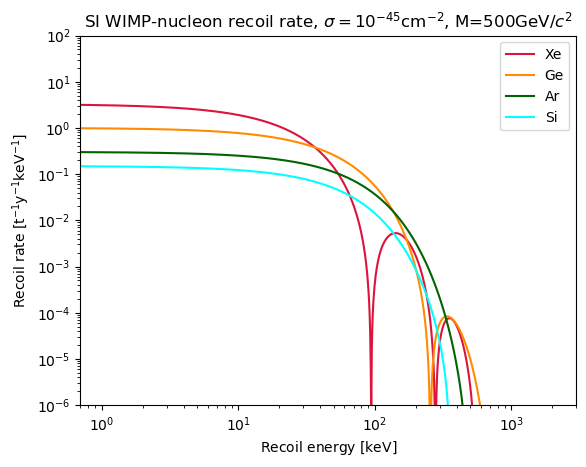

In [38]:
plt.clf()
mw = 500
etrue_centers = np.geomspace(0.1,1000,1000)
for color, target in zip(["crimson","darkorange","darkgreen","cyan"],["Xe","Ge","Ar","Si"]):
    r_new = wimprates.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_new, material=target)
    plt.plot(etrue_centers, r_new,color=color,linestyle="-", label=target)
plt.yscale("log")
plt.xlim(0.7,3000)
plt.yscale("log")
plt.ylim(1e-6,100)
plt.xscale("log")
plt.legend()
plt.xlabel("Recoil energy [$\mathrm{keV}$]")
plt.ylabel("Recoil rate [$\mathrm{t}^{-1}\mathrm{y}^{-1}\mathrm{keV}^{-1}$]")
plt.title("SI WIMP-nucleon recoil rate, $\sigma=10^{-45}\mathrm{cm}^{-2}$, M=$500\mathrm{GeV}/c^2$")
plt.savefig("wimprates_targets.png")
plt.show()

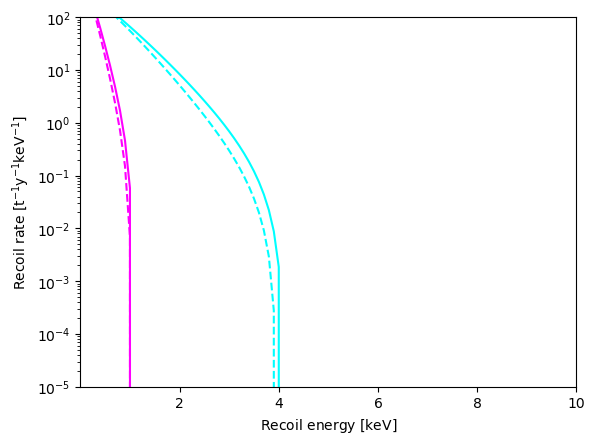

In [12]:
plt.clf()
etrue_centers = np.linspace(0.1,10,100)
for color, mw in zip(["k","magenta","cyan"],[0.2,3,6]):
    r_old = wimprates.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_old)
    r_new = wimprates.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_new)
    plt.plot(etrue_centers, r_old,color=color,linestyle="--")
    plt.plot(etrue_centers, r_new,color=color,linestyle="-")
plt.yscale("log")
plt.xlim(0.001,10)
plt.ylim(1e-5,100)
#plt.xscale("log")
plt.xlabel("Recoil energy [$\mathrm{keV}$]")
plt.ylabel("Recoil rate [$\mathrm{t}^{-1}\mathrm{y}^{-1}\mathrm{keV}^{-1}$]")
plt.show()

In [ ]:
for 

In [77]:
def earth_velocity(t, v_lsr=None, v_pec=None):
    """Returns 3d velocity of earth, in the galactic rest frame,
    in galactic coordinates.
    :param t: J2000.0 timestamp

    Values and formula from https://arxiv.org/abs/1209.3339
    Assumes earth circular orbit.
    """
    # e_1 and e_2 are the directions of earth's velocity at t1
    # and t1 + 0.25 year.
    e_1 = np.array([0.9931, 0.1170, -0.01032])
    e_2 = np.array([-0.0670, 0.4927, -0.8676])
    # t1 is the time of the vernal equinox, March 21. Does it matter what
    # year? Precession of equinox takes 25800 years so small effect.
    t1 = j2000(2000, 3, 21)
    # Angular frequency
    omega = 2 * np.pi / 365.25
    phi = omega * (t - t1)

    # Mean orbital velocity of the Earth (Lewin & Smith appendix B)
    v_orbit = 29.79 * nu.km / nu.s

    v_earth_sun = v_orbit * (e_1 * np.cos(phi) + e_2 * np.sin(phi))

    # Velocity of Local Standard of Rest
    v_lsr = np.array([0, 220, 0]) * nu.km/nu.s if v_lsr is None else v_lsr
    # Solar peculiar velocity
    v_pec = np.array([11, 12, 7]) * nu.km/nu.s if v_pec is None else v_pec

    return v_lsr + v_pec + v_earth_sun

In [78]:
 t1 = j2000(2000, 3, 21)

In [79]:
def v_earth(t=None, v_lsr=None, v_pec=None):
    """Return speed of earth relative to galactic rest frame
    :param t: J2000 timestamp or None
    """
    if t is None:
        # Velocity of earth/sun relative to gal. center
        # (eccentric orbit, so not equal to v_0)
        return 232 * nu.km / nu.s
    else:
        return np.sum(earth_velocity(t,v_lsr=v_lsr, v_pec = v_pec) ** 2) ** 0.5

In [80]:
def v_max(t=None, v_esc=None, v_lsr=None, v_pec=None):
    """Return maximum observable dark matter velocity on Earth."""
    v_esc = 544 * nu.km/nu.s if v_esc is None else v_esc  # default
    # args do not change value when you do a
    # reset_unit so this is necessary to avoid errors
    if t is None:
        return v_esc + v_earth(t,v_lsr=v_lsr, v_pec = v_pec)
    else:
        return v_esc + np.sum(earth_velocity(t,v_lsr=v_lsr, v_pec = v_pec) ** 2) ** 0.5

In [81]:
def observed_speed_dist(v, t=None, v_0=None, v_esc=None, v_lsr=None, v_pec=None):
    """Observed distribution of dark matter particle speeds on earth
    under the standard halo model.

    See my thesis for derivation ;-)
    If you find a paper where this formula is written out explicitly, please
    let me know. I spent a lot of time looking for this in vain.

    Optionally supply J2000.0 time t to take into account Earth's orbital
    velocity.

    Further inputs: scale velocity v_0 and escape velocity v_esc_value
    """
    v_0 = 220 * nu.km/nu.s if v_0 is None else v_0
    v_esc = 544 * nu.km/nu.s if v_esc is None else v_esc
    
    v_earth_t = v_earth(t,v_lsr=v_lsr, v_pec = v_pec)

    # Normalization constant, see Lewin&Smith appendix 1a
    _w = v_esc/v_0
    k = erf(_w) - 2/np.pi**0.5 * _w * np.exp(-_w**2)  # unitless

    # Maximum cos(angle) for this velocity, otherwise v0
    xmax = np.minimum(1,
                      (v_esc**2 - v_earth_t**2 - v**2)
                      / (2 * v_earth_t * v))
    # unitless

    y = (k * v / (np.pi**0.5 * v_0 * v_earth_t)
         * (np.exp(-((v-v_earth_t)/v_0)**2)
         - np.exp(-1/v_0**2 * (v**2 + v_earth_t**2
                  + 2 * v * v_earth_t * xmax))))
    # units / (velocity)

    # Zero if v > v_max
    try:
        len(v)
    except TypeError:
        # Scalar argument
        if v > v_max(t, v_esc,v_lsr=v_lsr, v_pec = v_pec):
            return 0
        else:
            return y
    else:
        # Array argument
        y[v > v_max(t, v_esc,v_lsr=v_lsr, v_pec = v_pec)] = 0
        return y

In [82]:
observed_speed_dist(220 * nu.km/nu.s, t=t1)

1.1375779881124087e-08

In [83]:
class StandardHaloModel:
    """
        class used to pass a halo model to the rate computation
        must contain:
        :param v_esc -- escape velocity
        :function velocity_dist -- function taking v,t
        giving normalised valocity distribution in earth rest-frame.
        :param rho_dm -- density in mass/volume of dark matter at the Earth
        The standard halo model also allows variation of v_0
        :param v_0
    """

    def __init__(self, v_0=None, v_esc=None, rho_dm=None,v_lsr = None, v_pec = None):
        self.v_0 = 220 * nu.km/nu.s if v_0 is None else v_0
        self.v_esc = 544 * nu.km/nu.s if v_esc is None else v_esc
        self.rho_dm = 0.3 * nu.GeV/nu.c0**2 / nu.cm**3 if rho_dm is None else rho_dm
        # Velocity of Local Standard of Rest
        self.v_lsr = np.array([0, 220, 0]) * nu.km/nu.s
        # Solar peculiar velocity
        self.v_pec = np.array([11, 12, 7]) * nu.km/nu.s

    def velocity_dist(self, v, t):
        # in units of per velocity,
        # v is in units of velocity
        return observed_speed_dist(v, t, self.v_0, self.v_esc,self.v_lsr, self.v_pec)

In [7]:


etrue_centers = np.logspace(-3,3,5001)
r_old = wimprates.rate_wimp_std(etrue_centers,mw=20,sigma_nucleon=1e-45, halo_model=halo_old)
r_new = wimprates.rate_wimp_std(etrue_centers,mw=20,sigma_nucleon=1e-45, halo_model=halo_new)



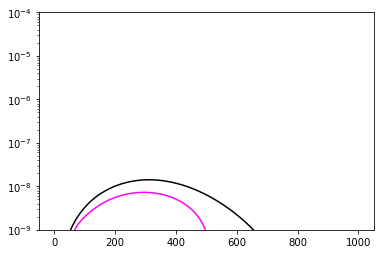

In [4]:
halo_old = wimprates.StandardHaloModel(v_0=235*nu.km/nu.s, v_esc=544*nu.km/nu.s)
halo_new = wimprates.StandardHaloModel(v_0=235*nu.km/nu.s, v_esc=300*nu.km/nu.s)
vs = np.linspace(0.001,1000*nu.km/nu.s,1001)
ys_old = halo_old.velocity_dist(vs,t=0.)
ys_new = halo_new.velocity_dist(vs,t=0.)
plt.clf()
plt.plot(vs/(nu.km/nu.s),ys_old,color="k")
plt.plot(vs/(nu.km/nu.s),ys_new,color="magenta")
plt.yscale("log")
plt.ylim(1e-9,1e-4)
plt.show()

In [5]:
etrue_centers = np.logspace(-3,3,5001)
r_old = wimprates.rate_wimp_std(etrue_centers,mw=500,sigma_nucleon=1e-45, halo_model=halo_old)
r_new = wimprates.rate_wimp_std(etrue_centers,mw=500,sigma_nucleon=1e-45, halo_model=halo_new)

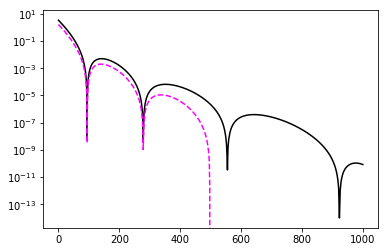

In [6]:
plt.clf()
plt.plot(etrue_centers, r_old,color="k")
plt.plot(etrue_centers, r_new,color="magenta",linestyle="--")
plt.yscale("log")
#plt.ylim(1,10)
plt.show()

In [5]:
import numericalunits as nu
import wimprates
import numpy as np

In [41]:
es = np.linspace(0,60,1000)
rate_sdp = wimprates.rate_wimp_std(es, 200, 1e-45, interaction="SD_p_central")
rate_sdn = wimprates.rate_wimp_std(es, 200, 1e-45, interaction="SD_n_central")
rate_si  = wimprates.rate_wimp_std(es, 200, 1e-45, interaction="SI")

In [42]:
import matplotlib.pyplot as plt

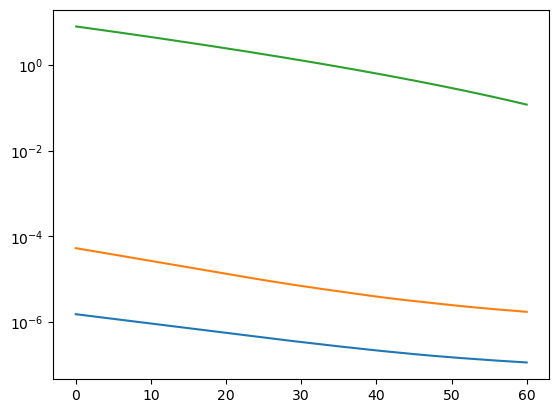

In [43]:
plt.clf()
plt.plot(es, rate_sdp)
plt.plot(es, rate_sdn)
plt.plot(es, rate_si)
plt.yscale("log")
#plt.xscale("log")
#plt.ylim(1,10)
plt.show()

In [44]:
np.sum(rate_si) / np.sum(rate_sdp)

nan

In [36]:
rate_si/rate_sdp

array([5144404.84099806, 5144214.99983004, 5144025.41817127, ...,
       1050017.20327597, 1049581.98352876, 1049146.89187974])

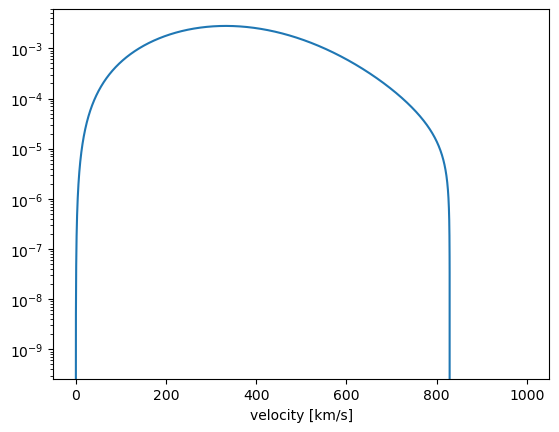

In [58]:
vs = np.linspace(-10,1000*nu.km/nu.s,10000)
rates = halo_new.velocity_dist(vs, t = 59.37)
plt.clf()
plt.plot(vs*(nu.s/nu.km), rates*(nu.km/nu.s))
plt.yscale("log")
plt.xlabel("velocity [km/s]")
plt.show()

In [57]:
np.sum((vs[1]-vs[0])*rates)

0.9864815717654336